
# Lab 9: Quantun Computing - Rabi Oscillations

Nombre estudiante: SantiagoAndrés Angulo Toro

c.c: 1001154362

## Exercise 1: $NH_3$ molecule

An example of the quantum oscillations in two-level systems may be rather unexpected; for example, the ammonium molecule

![NH3](../Sesiones/QC/figures/NH3.png)
![NH3](NH3.png)

 It has two symmetric states that differ by the inversion of the nitrogen atom relative to the plane of the three hydrogen atoms, which are weakly coupled due to quantum-mechanical tunneling of the nitrogen atom through the plane of the hydrogen atoms. Since for this particular molecule, in the absence of external fields, the level splitting $\Delta E$ corresponds to an experimentally convenient frequency $\Omega/2\pi\approx$ 24.79 GHz.

 1. Supose a detuning frequency $\Omega_R/2$.
 2. Compute the Rabi frequency for NH3 molecule in Hz and do a plot of the Rabi oscillation. Supose that the initial state is $\ket{2}$.

 [see](https://phys.libretexts.org/Bookshelves/Quantum_Mechanics/Essential_Graduate_Physics_-_Quantum_Mechanics_(Likharev)/05%3A_Some_Exactly_Solvable_Problems/5.01%3A_Two-level_Systems)

In [8]:
!pip install qiskit
!pip install qiskit_aer
!pip install pylatexenc

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

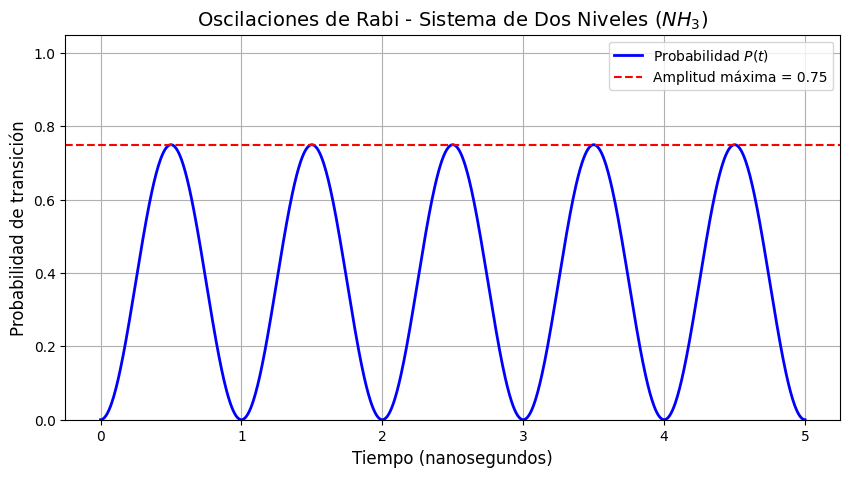

Frecuencia base NH3: 24.79 GHz
Amplitud máxima de oscilación debido al detuning: 75.00000000000001%


In [9]:
# Sabemos que la frecuencia experimental es aprox 24.79 GHz.
freq_0_GHz = 24.79
omega_0 = 2 * np.pi * freq_0_GHz * 1e9 # Frecuencia de transición teórica en rad/s

# Supongamos una frecuencia de Rabi generalizada arbitraria para la visualización (ej. 1 GHz)
Omega_R = 2 * np.pi * 1e9

Delta_omega = Omega_R / 2

omega_1 = np.sqrt(Omega_R**2 - Delta_omega**2)

# Genero un array de tiempo desde 0 hasta 5 nanosegundos para ver varias oscilaciones
t = np.linspace(0, 5e-9, 1000)

# Probabilidad de encontrar el sistema en el estado excitado (habiendo iniciado en el otro)
# Formula: P(t) = (omega_1^2 / Omega_R^2) * sin^2(Omega_R * t / 2)
amplitud = (omega_1**2) / (Omega_R**2) # Esto teóricamente dará  0.75
P_t = amplitud * (np.sin(Omega_R * t / 2))**2

#Graficar el resultado (Oscilaciones de Rabi)
plt.figure(figsize=(10, 5))
plt.plot(t * 1e9, P_t, 'b-', lw=2, label=r'Probabilidad $P(t)$')
plt.axhline(amplitud, color='r', linestyle='--', label=f'Amplitud máxima = {amplitud:.2f}')
plt.title(r'Oscilaciones de Rabi - Sistema de Dos Niveles ($NH_3$)', fontsize=14)
plt.xlabel('Tiempo (nanosegundos)', fontsize=12)
plt.ylabel('Probabilidad de transición', fontsize=12)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

print(f"Frecuencia base NH3: {freq_0_GHz} GHz")
print(f"Amplitud máxima de oscilación debido al detuning: {amplitud*100}%")

## Exercise: Bell state

1. Creates a quantum circuit for two qubits, consisting of the quantum gates needed to create a `Bell state`  (two entangled qubits). The quantum circuit then terminates with quantum measurements, extracting one bit from each qubit.

2. Add a third qubit by changing to QuantumCircuit(3), and add a second CX gate with qc.cx(1,2). The measurements should then change to 000 and 111, which means all three of these qubits have been entangled.

3. See your results shift by adding qc.x(1) to the end of the circuit.

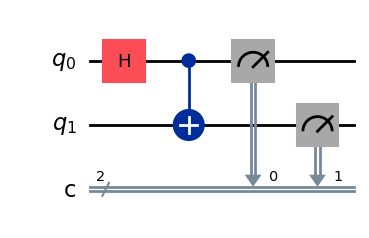

Resultados de medición para el Estado de Bell: {'00': 500, '11': 524}


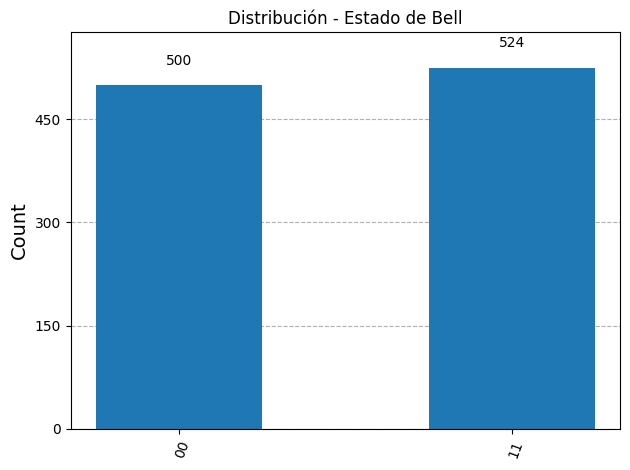

In [10]:
# Creamos un circuito con 2 qubits y 2 bits clásicos para la medición
qc_bell = QuantumCircuit(2, 2)

# Aplicamos la compuerta Hadamard al qubit 0 para crear superposición
qc_bell.h(0)

# Aplicamos la compuerta CNOT usando el qubit 0 como control y el 1 como objetivo
qc_bell.cx(0, 1)

# Medimos ambos qubits
qc_bell.measure([0, 1], [0, 1])

# Dibujamos el circuito
display(qc_bell.draw('mpl'))

# Simulamos el resultado
simulator = Aer.get_backend('qasm_simulator')
result_bell = simulator.run(qc_bell, shots=1024).result()
counts_bell = result_bell.get_counts()

print("Resultados de medición para el Estado de Bell:", counts_bell)
display(plot_histogram(counts_bell, title="Distribución - Estado de Bell"))

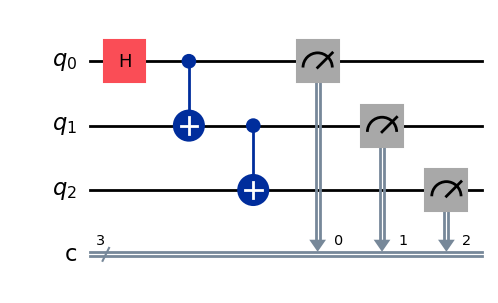

Resultados de medición para 3 Qubits entrelazados: {'000': 535, '111': 489}


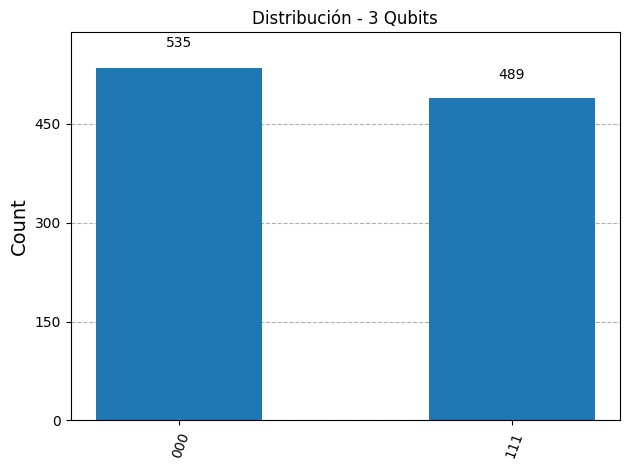

In [11]:
# Se requiere agregar un 3er qubit y entrelazarlo con otra CNOT

qc_3qubits = QuantumCircuit(3, 3)

qc_3qubits.h(0)        # Superposición en Q0
qc_3qubits.cx(0, 1)    # Entrelazamos Q0 y Q1
qc_3qubits.cx(1, 2)    # Entrelazamos Q1 y Q2

# Medición
qc_3qubits.measure([0, 1, 2], [0, 1, 2])

display(qc_3qubits.draw('mpl'))

result_3q = simulator.run(qc_3qubits, shots=1024).result()
counts_3q = result_3q.get_counts()

print("Resultados de medición para 3 Qubits entrelazados:", counts_3q)
# Los resultados deberían ser fuertemente dominados por '000' y '111'
display(plot_histogram(counts_3q, title="Distribución - 3 Qubits"))

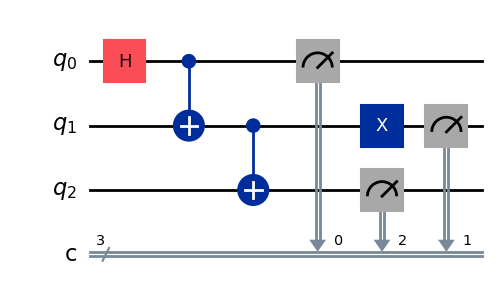

Resultados tras aplicar X(1): {'010': 529, '101': 495}


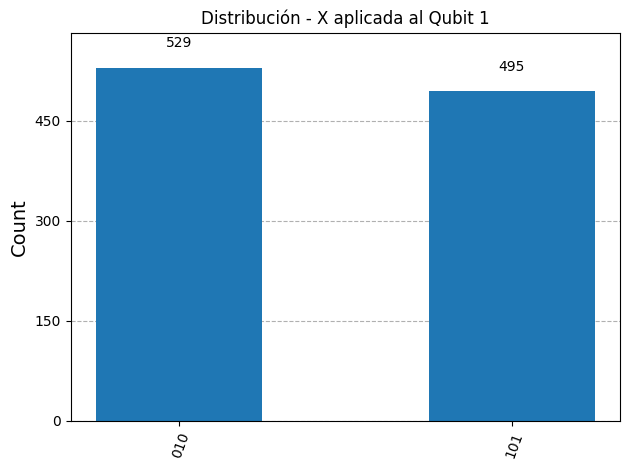

In [12]:
# Ahora agregamos una compuerta X (inversor/NOT cuántico) al qubit 1 antes de medir.

qc_shifted = QuantumCircuit(3, 3)

qc_shifted.h(0)
qc_shifted.cx(0, 1)
qc_shifted.cx(1, 2)

# Agregamos la compuerta Pauli-X (inversión) en el qubit 1
qc_shifted.x(1)

qc_shifted.measure([0, 1, 2], [0, 1, 2])

display(qc_shifted.draw('mpl'))

result_shifted = simulator.run(qc_shifted, shots=1024).result()
counts_shifted = result_shifted.get_counts()

print("Resultados tras aplicar X(1):", counts_shifted)
# Al aplicar un NOT (X) al qubit de en medio (q1), los estados '000' y '111'
# se transformarán (el bit central se voltea). Esperamos ver '010' y '101'.
display(plot_histogram(counts_shifted, title="Distribución - X aplicada al Qubit 1"))